In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("titanic")
print(df.head())
print("Shape:", df.shape)
print(df.columns)
print(df.dtypes)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Shape: (891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
survived     

In [2]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [3]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [4]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    print("\nFeature:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


Feature: survived
Mean: 0.3838383838383838
Median: 0.0
Mode: 0

Feature: pclass
Mean: 2.308641975308642
Median: 3.0
Mode: 3

Feature: age
Mean: 29.69911764705882
Median: 28.0
Mode: 24.0

Feature: sibsp
Mean: 0.5230078563411896
Median: 0.0
Mode: 0

Feature: parch
Mean: 0.38159371492704824
Median: 0.0
Mode: 0

Feature: fare
Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05


In [5]:
for col in numeric_cols:
    print("\nFeature:", col)
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())
    print("Range:", df[col].max()-df[col].min())
    print("IQR:", df[col].quantile(0.75)-df[col].quantile(0.25))



Feature: survived
Variance: 0.2367722165474984
Standard Deviation: 0.4865924542648585
Range: 1
IQR: 1.0

Feature: pclass
Variance: 0.6990151199889065
Standard Deviation: 0.8360712409770513
Range: 2
IQR: 1.0

Feature: age
Variance: 211.0191247463081
Standard Deviation: 14.526497332334044
Range: 79.58
IQR: 17.875

Feature: sibsp
Variance: 1.2160430774662894
Standard Deviation: 1.1027434322934275
Range: 8
IQR: 1.0

Feature: parch
Variance: 0.6497282437357467
Standard Deviation: 0.8060572211299559
Range: 6
IQR: 0.0

Feature: fare
Variance: 2469.436845743117
Standard Deviation: 49.693428597180905
Range: 512.3292
IQR: 23.0896


In [6]:
for col in numeric_cols:
    print("\nFeature:", col)
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())


Feature: survived
Skewness: 0.4785234382949897
Kurtosis: -1.775004671066304

Feature: pclass
Skewness: -0.6305479068752845
Kurtosis: -1.2800149715782825

Feature: age
Skewness: 0.38910778230082704
Kurtosis: 0.17827415364210353

Feature: sibsp
Skewness: 3.6953517271630565
Kurtosis: 17.880419726645968

Feature: parch
Skewness: 2.7491170471010933
Kurtosis: 9.778125179021648

Feature: fare
Skewness: 4.787316519674893
Kurtosis: 33.39814088089868


In [7]:
group = df.groupby("survived")

print("\nGroup Mean")
print(group[numeric_cols].mean())

print("\nGroup Standard Deviation")
print(group[numeric_cols].std())

print("\nAggregated Statistics (Age)")
print(group["age"].agg(["mean","median","std","skew"]))


Group Mean
          survived    pclass        age     sibsp     parch       fare
survived                                                              
0              0.0  2.531876  30.626179  0.553734  0.329690  22.117887
1              1.0  1.950292  28.343690  0.473684  0.464912  48.395408

Group Standard Deviation
          survived    pclass        age     sibsp     parch       fare
survived                                                              
0              0.0  0.735805  14.172110  1.288399  0.823166  31.388207
1              0.0  0.863321  14.950952  0.708688  0.771712  66.596998

Aggregated Statistics (Age)
               mean  median        std      skew
survived                                        
0         30.626179    28.0  14.172110  0.585584
1         28.343690    28.0  14.950952  0.180458


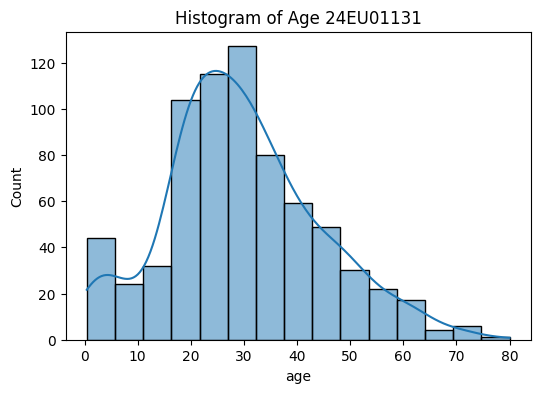

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=15, kde=True)
plt.title("Histogram of Age 24EU01131")
plt.show()

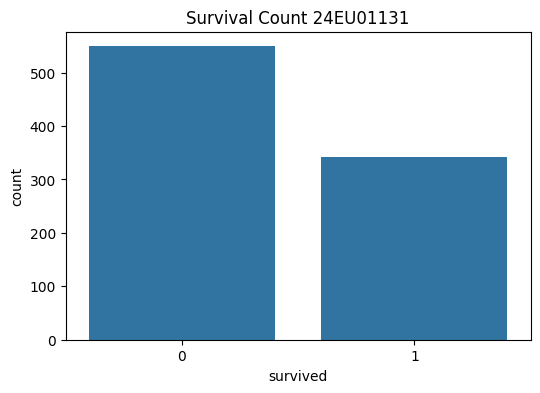

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="survived", data=df)
plt.title("Survival Count 24EU01131")
plt.show()

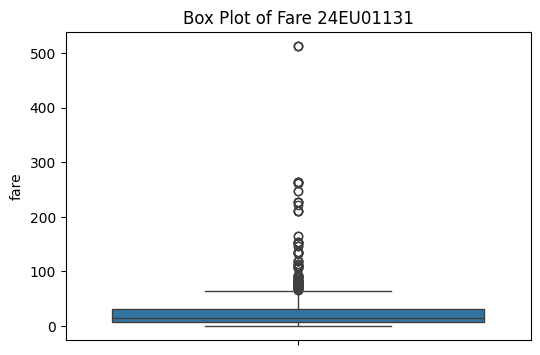

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(y="fare", data=df)
plt.title("Box Plot of Fare 24EU01131")
plt.show()

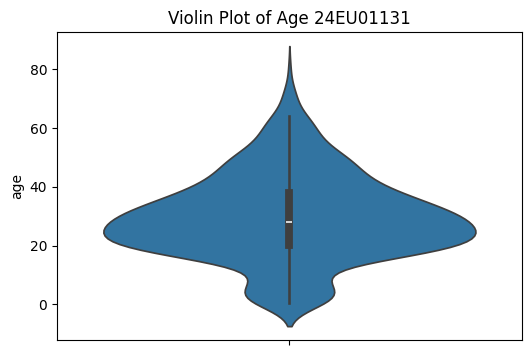

In [11]:
plt.figure(figsize=(6,4))
sns.violinplot(y="age", data=df)
plt.title("Violin Plot of Age 24EU01131")
plt.show()


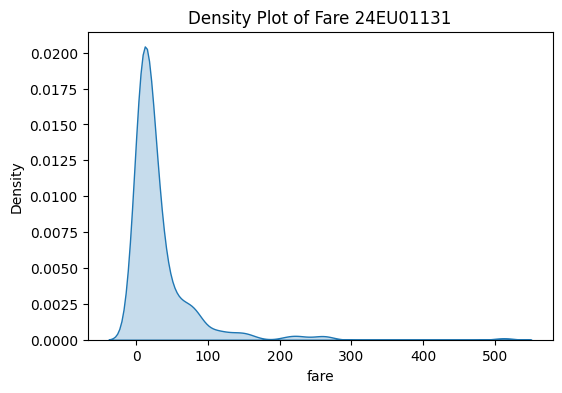

In [12]:
plt.figure(figsize=(6,4))
sns.kdeplot(df["fare"], fill=True)
plt.title("Density Plot of Fare 24EU01131")
plt.show()

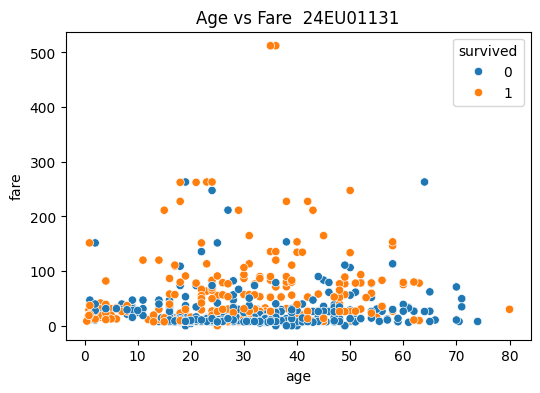

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="fare",
                hue="survived", data=df)
plt.title("Age vs Fare  24EU01131")
plt.show()

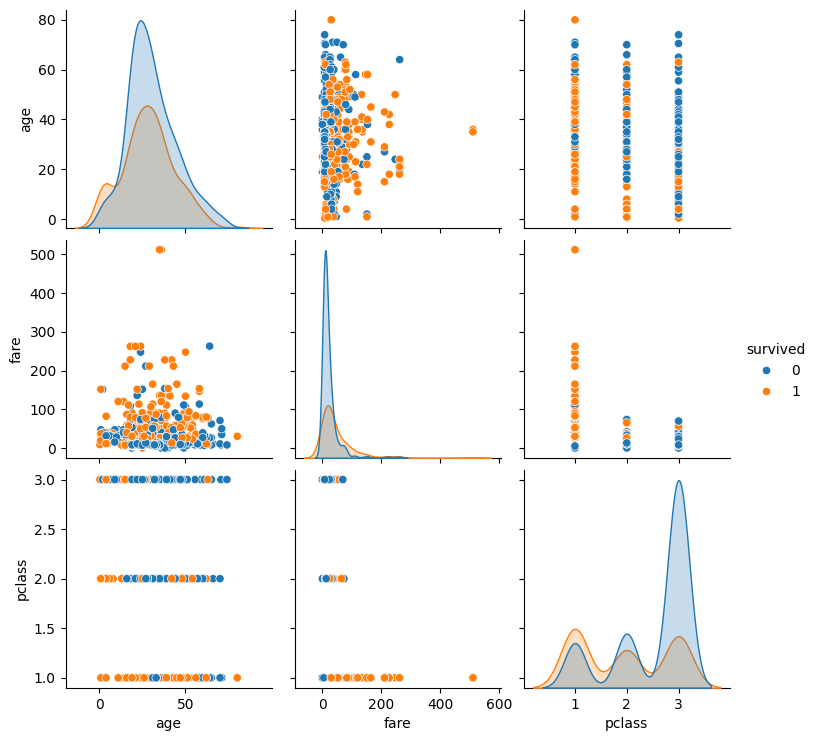

24EU01131


In [14]:
sns.pairplot(df[["age","fare","pclass","survived"]], hue="survived")
plt.show()
print("24EU01131")

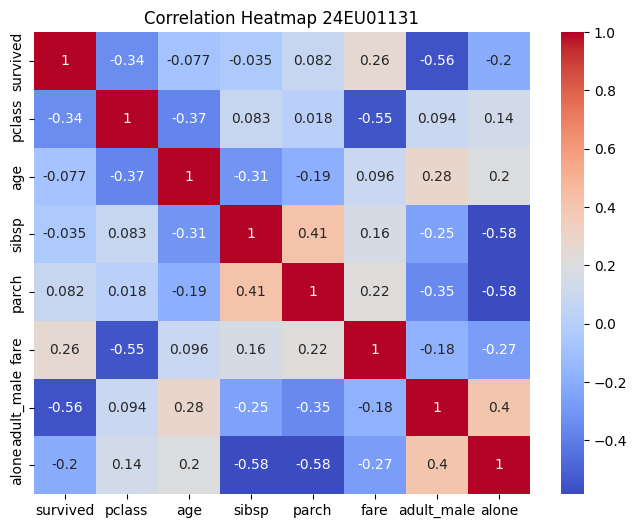

In [15]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap 24EU01131")
plt.show()

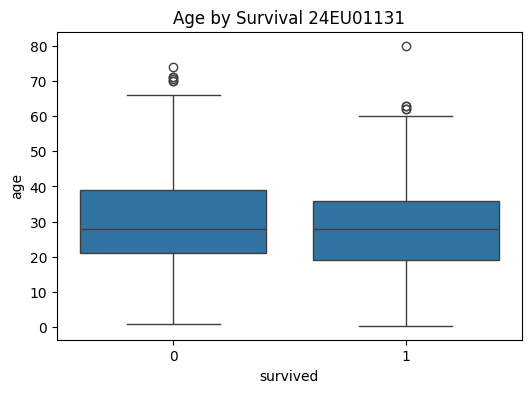

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x="survived", y="age", data=df)
plt.title("Age by Survival 24EU01131")
plt.show()

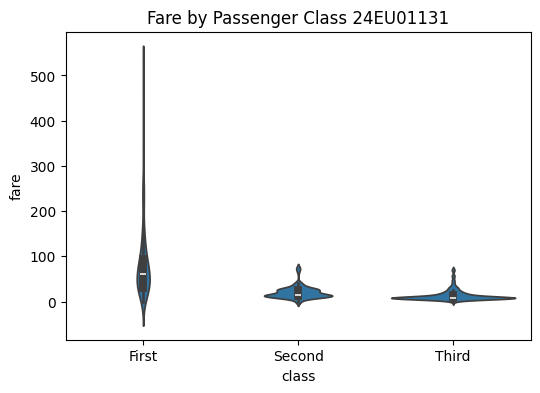

In [17]:
plt.figure(figsize=(6,4))
sns.violinplot(x="class", y="fare", data=df)
plt.title("Fare by Passenger Class 24EU01131")
plt.show()


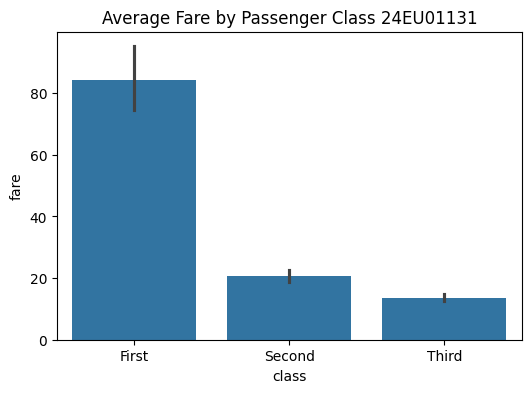

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x="class", y="fare", data=df)
plt.title("Average Fare by Passenger Class 24EU01131")
plt.show()

In [19]:
print("Duplicate Rows:", df.duplicated().sum())

# Class distribution
print("\nSurvival Distribution")
print(df["survived"].value_counts())


Duplicate Rows: 107

Survival Distribution
survived
0    549
1    342
Name: count, dtype: int64


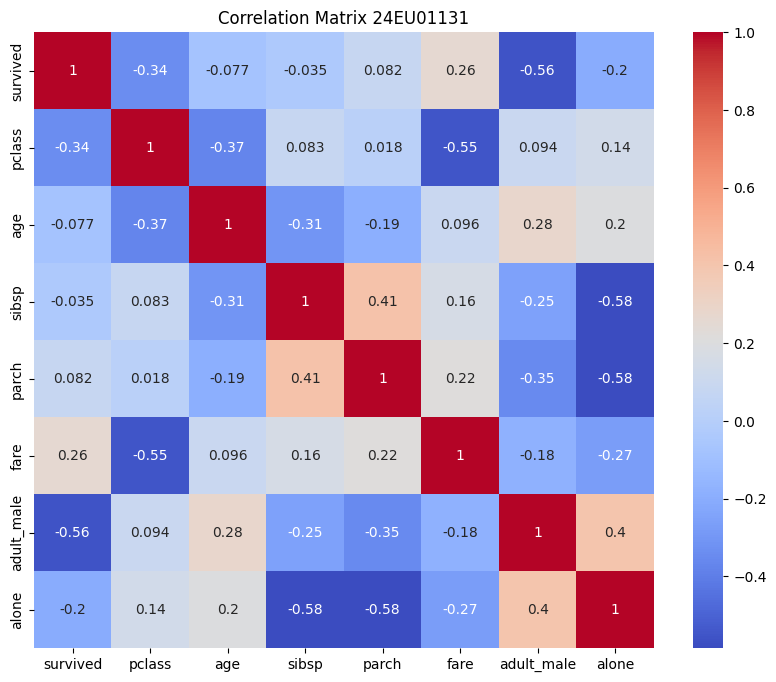

In [20]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,cmap="coolwarm")
plt.title("Correlation Matrix 24EU01131")
plt.show()

In [21]:
print("\nCorrelation with Survival")
print(corr["survived"].sort_values(ascending=False))
print("\nUnique Values")
print(df.nunique())
print("\nRandom Samples")
print(df.sample(5))


Correlation with Survival
survived      1.000000
fare          0.257307
parch         0.081629
sibsp        -0.035322
age          -0.077221
alone        -0.203367
pclass       -0.338481
adult_male   -0.557080
Name: survived, dtype: float64

Unique Values
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

Random Samples
     survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
257         1       1  female  30.0      0      0  86.5000        S  First   
601         0       3    male   NaN      0      0   7.8958        S  Third   
160         0       3    male  44.0      0      1  16.1000        S  Third   
204         1       3    male  18.0      0      0   8.0500        S  Third   
67          0       3    male  19.0    